In [240]:
import pandas as pd
import numpy as np

In [241]:
df = pd.read_csv("House Price Prediction Dataset.csv")
print(df.head())

   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  


In [242]:
df.shape

(2000, 10)

In [243]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [244]:
df.duplicated().sum()

np.int64(0)

In [245]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [246]:
df = df.drop("Id", axis=1)

In [247]:
df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3592,2,2,3,1938,Downtown,Good,No,266746
3,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [248]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

print(num_cols)

Index(['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price'], dtype='object')


In [249]:
df[num_cols].describe()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [250]:
num_cols = ["Area", "Bedrooms", "Bathrooms", "Floors", "YearBuilt", "Price"]

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}: {len(outliers)} outliers")

Area: 0 outliers


Bedrooms: 0 outliers
Bathrooms: 0 outliers
Floors: 0 outliers
YearBuilt: 0 outliers
Price: 0 outliers


In [251]:
cat_cols = df.select_dtypes(include="object").columns

print(cat_cols)

Index(['Location', 'Condition', 'Garage'], dtype='object')


In [252]:
df = pd.get_dummies(
    df,
    columns=["Location", "Condition", "Garage"],
    drop_first=True
)

In [253]:
print(df.dtypes)

Area                 int64
Bedrooms             int64
Bathrooms            int64
Floors               int64
YearBuilt            int64
Price                int64
Location_Rural        bool
Location_Suburban     bool
Location_Urban        bool
Condition_Fair        bool
Condition_Good        bool
Condition_Poor        bool
Garage_Yes            bool
dtype: object


In [254]:
current_year = 2026

df["HouseAge"] = current_year - df["YearBuilt"]

df.drop("YearBuilt", axis=1, inplace=True)

In [255]:
df.head()

,Area,Bedrooms,Bathrooms,Floors,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes,HouseAge
0,1360,5,4,3,149919,False,False,False,False,False,False,False,56
1,4272,5,4,3,424998,False,False,False,False,False,False,False,68
2,3592,2,2,3,266746,False,False,False,False,True,False,False,88
3,966,4,2,2,244020,False,True,False,True,False,False,True,124
4,4926,1,4,2,636056,False,False,False,True,False,False,True,51


In [256]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Area               2000 non-null   int64
 1   Bedrooms           2000 non-null   int64
 2   Bathrooms          2000 non-null   int64
 3   Floors             2000 non-null   int64
 4   Price              2000 non-null   int64
 5   Location_Rural     2000 non-null   bool 
 6   Location_Suburban  2000 non-null   bool 
 7   Location_Urban     2000 non-null   bool 
 8   Condition_Fair     2000 non-null   bool 
 9   Condition_Good     2000 non-null   bool 
 10  Condition_Poor     2000 non-null   bool 
 11  Garage_Yes         2000 non-null   bool 
 12  HouseAge           2000 non-null   int64
dtypes: bool(7), int64(6)
memory usage: 107.6 KB


In [257]:
print(df.corr(numeric_only=True)["Price"].sort_values(ascending=False))

Price                1.000000
Floors               0.055890
Condition_Fair       0.049218
Location_Suburban    0.040303
Garage_Yes           0.002842
Location_Rural       0.001890
Area                 0.001542
Bedrooms            -0.003471
HouseAge            -0.004845
Bathrooms           -0.015737
Condition_Good      -0.017179
Condition_Poor      -0.018437
Location_Urban      -0.038312
Name: Price, dtype: float64


In [259]:
df[["Area", "Price"]].sample(10)

,Area,Price
1772,4948,268850
39,741,218393
1538,2546,146453
1271,1325,232394
1689,2338,548185
1339,4278,530545
268,1684,195109
593,2484,922402
1287,2190,641759
968,4483,434325


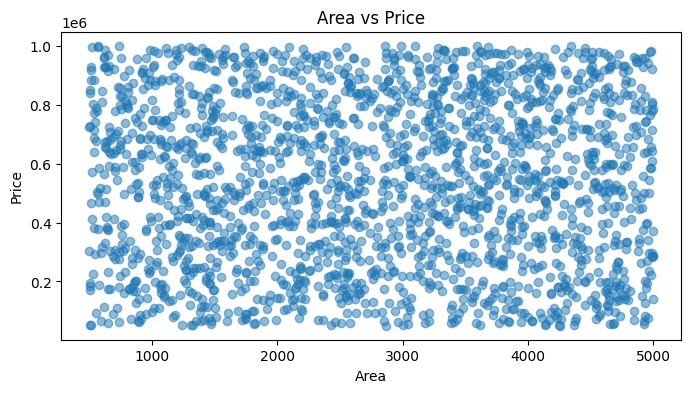

In [260]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.scatter(df["Area"], df["Price"], alpha=0.5)

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")

plt.show()

In [ ]:
X = df.drop("Price", axis=1)

y = df["Price"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (1600, 12)
X_test shape : (400, 12)
y_train shape: (1600,)
y_test shape : (400,)


In [262]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
y_pred = model.predict(X_test)

In [264]:
print(y_pred[:5])

[521988.22189839 549119.31196651 487101.22235594 539752.7439933
 553242.24872512]


In [265]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 243241.97758826384


In [266]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 279859.72583784326


In [267]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: -0.006717808430749761


In [268]:
train_r2 = model.score(X_train, y_train)
test_r2 = model.score(X_test, y_test)

print("Train R²:", train_r2)
print("Test R² :", test_r2)

Train R²: 0.009856184863687778
Test R² : -0.006717808430749761


In [269]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [270]:
y_pred_dt = dt.predict(X_test)
print(y_pred_dt[:5])

[430129. 764618. 960226. 485485. 745494.]


In [271]:
train_r2_dt = dt.score(X_train, y_train)
test_r2_dt = dt.score(X_test, y_test)

print("Train R²:", train_r2_dt)
print("Test R² :", test_r2_dt)

Train R²: 1.0
Test R² : -1.0544310850282996


In [272]:
print("Linear Regression Test R² :", test_r2)
print("Decision Tree Test R²    :", test_r2_dt)

Linear Regression Test R² : -0.006717808430749761
Decision Tree Test R²    : -1.0544310850282996


In [273]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100,random_state=42)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [274]:
y_pred_rf = rf.predict(X_test)
print(y_pred_rf[:5])

[633430.16 473509.06 550000.97 514940.58 530079.73]


In [275]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [276]:
y_pred_xgb = xgb.predict(X_test)
print(y_pred_xgb[:5])

[691733.3  476652.75 351142.44 541449.06 450150.12]


In [277]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [278]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [279]:
y_pred_knn = knn.predict(X_test_scaled)
print(y_pred_knn[:5])

[278968.2 397279.6 287849.4 224957.2 616383.6]


In [280]:
from sklearn.svm import SVR

svr = SVR()

svr.fit(X_train_scaled, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [281]:
y_pred_svr = svr.predict(X_test_scaled)
print(y_pred_svr[:5])

[533461.3252891  533462.50771346 533452.45774644 533455.67901274
 533456.67983743]
